In [ ]:
!pip install plotly
!pip install ipywidgets
!pip install anywidget

In [2]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy import stats


### Plot the S2 tesselation results

In [3]:
from pathlib import Path
import importlib
import pickle

# --- Locate TOML ---
# Set toml_file_name here, or leave as None to default to the first *.toml in cwd
toml_file_name = None  # e.g. "params_20260101_RyR_tutorial.toml"

if toml_file_name is None:
    candidates = sorted(Path.cwd().glob("*.toml"))
    if not candidates:
        raise FileNotFoundError("No .toml file found in current directory.")
    toml_file_name = candidates[0].name
    print(f"Auto-detected TOML: {toml_file_name}")

toml_file_name = toml_file_name.strip()
if not toml_file_name.endswith(".toml"):
    toml_file_name += ".toml"

toml_path = Path.cwd() / toml_file_name
print(f"Using TOML file: {toml_path}")

try:
    toml_parser = importlib.import_module("tomllib")   # Python 3.11+
except ModuleNotFoundError:
    toml_parser = importlib.import_module("tomli")     # fallback

with toml_path.open("rb") as f:
    toml_config = toml_parser.load(f)

# project_name may be nested under [params] or at top level
params_section = toml_config.get("params", toml_config)
project_name = params_section.get("project_name", "")
print(f"project_name: {project_name}")

# --- Load pd_data.pkl from the output directory ---
output_dir = Path.cwd() / "output" / project_name
pkl_path = output_dir / "pd_data.pkl"
print(f"Loading: {pkl_path}")

with open(pkl_path, "rb") as f:
    pd_data = pickle.load(f)

print(f"\nAvailable keys: {list(pd_data.keys())}")
print(f"  bin_centers shape : {pd_data['bin_centers'].shape}")
print(f"  occupancy_full shape: {pd_data['occupancy_full'].shape}")
print(f"  pos_full shape    : {pd_data['pos_full'].shape}")
print(f"  pos_thresholded   : {pd_data['pos_thresholded'].shape}")
print(f"  thres_low / high  : {pd_data['thres_low']} / {pd_data['thres_high']}")


Auto-detected TOML: params_20260101_RyR_tutorial.toml
Using TOML file: /scratch/rdsouza/ManifoldEM_tests/ManifoldEM/tutorial/RyR1GCs_demo/params_20260101_RyR_tutorial.toml
project_name: 20260101_RyR_tutorial
Loading: /scratch/rdsouza/ManifoldEM_tests/ManifoldEM/tutorial/RyR1GCs_demo/output/20260101_RyR_tutorial/pd_data.pkl

Available keys: ['thres_low', 'thres_high', 'bin_centers', 'defocus', 'microscope_origin', 'pos_raw', 'pos_full', 'quats_raw', 'quats_full', 'image_indices_full', 'thres_ids', 'occupancy_full', 'anchors', 'trash_ids', 'reembed_ids', 'neighbor_graph', 'neighbor_subgraph', 'neighbor_graph_pruned', 'neighbor_subgraph_pruned', 'pos_thresholded', 'theta_thresholded', 'phi_thresholded', 'cluster_ids', 'image_is_mirrored']
  bin_centers shape : (3, 2005)
  occupancy_full shape: (2005,)
  pos_full shape    : (3, 14491)
  pos_thresholded   : (3, 53)
  thres_low / high  : 100 / 2000


### S2 orientation distribution (interactive Plotly)

Points are the **tessellation bin centres** on the unit sphere S2.  
Colour = particle occupancy per bin (number of cryo-EM images whose orientation maps to that bin).  
**Thresholded PDs** (active projection directions after low/high occupancy cuts) are overlaid as larger red markers.


In [ ]:
# plotly for 3D interactive visualization, ipywidgets for interactivity in Jupyter
import ipywidgets as widgets
from IPython.display import display
import matplotlib.image as mpimg

# ── Data from pd_data ─────────────────────────────────────────────────────
bin_centers        = pd_data['bin_centers']        # (3, 2005)
occupancy          = pd_data['occupancy_full']      # (2005,)
pos_thres          = pd_data['pos_thresholded']     # (3, 53)
phi_thres          = pd_data['phi_thresholded']     # (53,)  degrees
theta_thres        = pd_data['theta_thresholded']   # (53,)  degrees
pos_full           = pd_data['pos_full']            # (3, 14491)
thres_ids          = list(pd_data['thres_ids'])     # [87, 118, ...]  bin indices for active PDs

# topos base dir
topos_dir = output_dir / 'topos'

# ── KDE density on sub-sampled particle cloud (mirrors s2_view.py) ────────
rng    = np.random.default_rng(42)
n_show = min(5000, pos_full.shape[1])
idx    = rng.choice(pos_full.shape[1], n_show, replace=False)
pf     = pos_full[:, idx]
kde     = stats.gaussian_kde(pf)
density = kde(pf);  density /= density.max()

# ── Reference sphere surface ──────────────────────────────────────────────
u, v = np.linspace(0, 2*np.pi, 60), np.linspace(0, np.pi, 30)
sphere = go.Surface(
    x=np.outer(np.cos(u), np.sin(v)),
    y=np.outer(np.sin(u), np.sin(v)),
    z=np.outer(np.ones_like(u), np.cos(v)),
    colorscale=[[0, 'lightgrey'], [1, 'lightgrey']],
    opacity=0.10, showscale=False, hoverinfo='skip', name='Unit sphere',
)

# ── All bin centres coloured by occupancy ─────────────────────────────────
bins_trace = go.Scatter3d(
    x=bin_centers[0], y=bin_centers[1], z=bin_centers[2],
    mode='markers',
    marker=dict(
        size=4, color=occupancy, colorscale='Viridis',
        colorbar=dict(title='Occupancy<br>(particles/bin)', thickness=16, x=1.02),
        opacity=0.80, line=dict(width=0),
    ),
    text=[f'bin {i}<br>occ = {o}' for i, o in enumerate(occupancy)],
    hovertemplate='%{text}<br>(%{x:.3f}, %{y:.3f}, %{z:.3f})<extra></extra>',
    name='Bin centres',
)

# ── Per-particle density cloud (hidden by default) ────────────────────────
particles_trace = go.Scatter3d(
    x=pf[0], y=pf[1], z=pf[2], mode='markers',
    marker=dict(size=2, color=density, colorscale='Hot', opacity=0.35, line=dict(width=0)),
    hovertemplate='(%{x:.3f}, %{y:.3f}, %{z:.3f})<extra></extra>',
    name=f'Particles (n={n_show}, KDE density)',
    visible='legendonly',
)

# ── Active PDs — clickable diamonds ───────────────────────────────────────
thres_trace = go.Scatter3d(
    x=pos_thres[0], y=pos_thres[1], z=pos_thres[2], mode='markers',
    marker=dict(size=8, color='red', opacity=0.95, symbol='diamond',
                line=dict(color='darkred', width=1)),
    text=[f'PD {i+1}<br>φ={phi_thres[i]:.1f}°  θ={theta_thres[i]:.1f}°'
          for i in range(len(phi_thres))],
    hovertemplate='%{text}<br>(%{x:.3f}, %{y:.3f}, %{z:.3f})<extra></extra>',
    name=f'Active PDs (n={pos_thres.shape[1]})  ← click for class avg',
)

# ── FigureWidget (required for on_click callbacks) ────────────────────────
fig = go.FigureWidget(data=[sphere, bins_trace, thres_trace, particles_trace])
fig.update_layout(
    title=dict(text='S2 Orientation Distribution — ' + project_name, x=0.5),
    scene=dict(
        xaxis=dict(title='x', showgrid=False, zeroline=False),
        yaxis=dict(title='y', showgrid=False, zeroline=False),
        zaxis=dict(title='z', showgrid=False, zeroline=False),
        aspectmode='cube', bgcolor='rgb(240,240,248)',
    ),
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.7)'),
    margin=dict(l=0, r=0, b=0, t=50),
    height=680,
)

# ── Widgets for the class-average panel ───────────────────────────────────
status_label = widgets.Label(
    value='  ▶  Click a red diamond to view its 2D class average.',
    style={'font_size': '13px'},
)
avg_out = widgets.Output()

# ── Click callback ────────────────────────────────────────────────────────
def on_pd_click(trace, points, selector):
    if not points.point_inds:
        return
    pd_idx   = points.point_inds[0]
    prd_num  = pd_idx + 1                             # folders are 1-based: PrD_1, PrD_2, …
    img_path = topos_dir / f'PrD_{prd_num}' / 'class_avg.png'

    status_label.value = (f'  PrD {prd_num}  |  φ={phi_thres[pd_idx]:.1f}°  '
                          f'θ={theta_thres[pd_idx]:.1f}°  |  '
                          f'occ = {occupancy[thres_ids[pd_idx]]}')

    with avg_out:
        avg_out.clear_output(wait=True)

        if not img_path.exists():
            print(f'File not found: {img_path}')
            return

        fig2, axes = plt.subplots(1, 2, figsize=(9, 4.5))

        # Left: pre-computed 2D class average
        img = mpimg.imread(str(img_path))
        axes[0].imshow(img, cmap='gray' if img.ndim == 2 else None)
        axes[0].set_title(f'2D Class Average  —  PrD {prd_num}\n'
                          f'φ={phi_thres[pd_idx]:.1f}°  θ={theta_thres[pd_idx]:.1f}°  '
                          f'occ={occupancy[thres_ids[pd_idx]]}',
                          fontsize=11)
        axes[0].axis('off')

        # Right: occupancy bar chart with this PD highlighted
        occ_active = [occupancy[thres_ids[i]] for i in range(len(thres_ids))]
        axes[1].bar(range(1, len(thres_ids) + 1), occ_active, color='steelblue', edgecolor='none')
        axes[1].bar(prd_num, occ_active[pd_idx], color='crimson', label=f'PrD {prd_num}')
        axes[1].axhline(pd_data['thres_low'],  color='red',   lw=1, ls='--', label='low thresh')
        axes[1].axhline(pd_data['thres_high'], color='green', lw=1, ls='--', label='high thresh')
        axes[1].set_xlabel('PrD number');  axes[1].set_ylabel('Occupancy')
        axes[1].set_title('Occupancy of active PDs', fontsize=11)
        axes[1].legend(fontsize=9)

        plt.tight_layout()
        plt.show()

# Attach to the diamond trace (index 2 in [sphere, bins, thres, particles])
fig.data[2].on_click(on_pd_click)

# ── Display everything ────────────────────────────────────────────────────
display(widgets.VBox([fig, status_label, avg_out]))
print(f"Active PDs: {pos_thres.shape[1]}  |  Total bins: {len(occupancy)}  |  Total particles: {pos_full.shape[1]}")


    'data': [{'colorscale': [[0, 'lightgrey'], [1, 'lightgrey']],
              …

Active PDs: 53  |  Total bins: 2005  |  Total particles: 14491


# Plot diffusion map results

### Per-PrD eigenvector viewer

Select a PrD with the slider (or click a diamond above — the slider updates automatically).  
**Tab 1** shows the eigenvalue scree plot. **Tab 2** shows the eigenvector movies (`psi_1` … `psi_8`).


In [5]:
import base64
from IPython.display import HTML

# ── Shared state: slider updated by sphere-click callback above ───────────
n_prds = pos_thres.shape[1]

prd_slider = widgets.IntSlider(
    value=1, min=1, max=n_prds, step=1,
    description='PrD:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='420px'),
)
prd_info = widgets.Label(value='', layout=widgets.Layout(width='400px'))

# Patch the S2 click callback to also drive this slider
_orig_on_pd_click = on_pd_click
def _patched_on_pd_click(trace, points, selector):
    _orig_on_pd_click(trace, points, selector)
    if points.point_inds:
        prd_slider.value = points.point_inds[0] + 1
fig.data[2].on_click(_patched_on_pd_click)

# ── Output areas ──────────────────────────────────────────────────────────
scree_out  = widgets.Output()
movies_out = widgets.Output()

tabs = widgets.Tab(children=[scree_out, movies_out])
tabs.set_title(0, 'Scree plot')
tabs.set_title(1, 'Eigenvector movies')

# ── Helper: load GIF as base64 HTML img tag ───────────────────────────────
def _gif_html(path, width=180):
    with open(path, 'rb') as f:
        b64 = base64.b64encode(f.read()).decode()
    return (f'<div style="display:inline-block;margin:4px;text-align:center">'
            f'<img src="data:image/gif;base64,{b64}" width="{width}"><br>'
            f'<small>{path.stem}</small></div>')

# ── Render function called on slider change ───────────────────────────────
def render_prd(change):
    prd_num  = prd_slider.value
    pd_idx   = prd_num - 1
    prd_dir  = topos_dir / f'PrD_{prd_num}'

    prd_info.value = (f'PrD {prd_num}  |  φ={phi_thres[pd_idx]:.1f}°  '
                      f'θ={theta_thres[pd_idx]:.1f}°  |  '
                      f'occ = {occupancy[thres_ids[pd_idx]]}')

    # ── Scree plot ────────────────────────────────────────────────────────
    with scree_out:
        scree_out.clear_output(wait=True)
        eig_file = prd_dir / 'eig_spec.txt'
        if not eig_file.exists():
            print(f'eig_spec.txt not found: {eig_file}')
        else:
            data  = np.loadtxt(eig_file)
            eig_idx = data[:, 0].astype(int)
            eig_val = data[:, 1]
            n_gifs  = len(list(prd_dir.glob('psi_*.gif')))

            fig_s, ax = plt.subplots(figsize=(6, 3.5))
            ax.bar(eig_idx, eig_val, color='steelblue', edgecolor='none')
            # Highlight the eigenvectors that have movies
            ax.bar(eig_idx[:n_gifs], eig_val[:n_gifs], color='crimson',
                   edgecolor='none', label=f'psi with movies (1–{n_gifs})')
            ax.set_xlabel('Eigenvalue index')
            ax.set_ylabel('Eigenvalue')
            ax.set_title(f'Eigenvalue spectrum  —  PrD {prd_num}', fontsize=11)
            ax.legend(fontsize=9)
            plt.tight_layout()
            plt.show()

    # ── Eigenvector movies ────────────────────────────────────────────────
    with movies_out:
        movies_out.clear_output(wait=True)
        gifs = sorted(prd_dir.glob('psi_*.gif'),
                      key=lambda p: int(p.stem.split('_')[1]))
        if not gifs:
            print(f'No .gif files found in {prd_dir}')
        else:
            html_parts = [f'<h4 style="margin:6px 0">PrD {prd_num} — eigenvector movies</h4>']
            html_parts += [_gif_html(g) for g in gifs]
            display(HTML(''.join(html_parts)))

# Trigger on slider change and render initial state
prd_slider.observe(render_prd, names='value')
render_prd(None)

# ── Layout ────────────────────────────────────────────────────────────────
display(widgets.VBox([
    widgets.HBox([prd_slider, prd_info]),
    tabs,
]))


### Diffusion map analysis (per PrD)

Driven by the same PrD slider above (or click a diamond on the S2 sphere).

**Row 1 — Left:** pairwise image distance matrix `D`, rows/columns reordered by `posPath` (the diffusion-derived conformational ordering). A well-behaved manifold shows a band-diagonal structure.  
**Row 1 — Right:** Ferguson plot — `ln Σ Wᵢⱼ` vs `ln ε` scatter with tanh fit. The inflection gives the optimal kernel width σ; the slope at the inflection estimates the intrinsic dimensionality.  
**Row 2:** ψ₁ vs ψ₂ diffusion map embedding coloured three ways: conformational order (`posPath`), Riemannian density (`μ`), and in-plane rotation angle.


In [6]:
import h5py

dist_dir    = output_dir / 'distances'
diffmap_dir = output_dir / 'diff_maps'

dm_out = widgets.Output()

def render_diffmap(change):
    prd_num  = prd_slider.value
    pd_idx   = prd_num - 1   # files are 0-indexed

    dist_file    = dist_dir    / f'IMGs_prD_{pd_idx}.h5'
    diffmap_file = diffmap_dir / f'gC_trimmed_psi_prD_{pd_idx}.h5'

    with dm_out:
        dm_out.clear_output(wait=True)

        missing = [p for p in [dist_file, diffmap_file] if not p.exists()]
        if missing:
            for p in missing:
                print(f'Not found: {p}')
            return

        # ── Load ──────────────────────────────────────────────────────────
        with h5py.File(dist_file, 'r') as f:
            D         = f['D'][:]           # (N, N) pairwise image distances
            rotations = f['rotations'][:]   # (N,)   in-plane rotation angles (rad)

        with h5py.File(diffmap_file, 'r') as f:
            psi      = f['psi'][:]          # (N, 15) eigenvectors (trivial removed)
            logEps   = f['logEps'][:]       # (1501,)
            logSumWij= f['logSumWij'][:]    # (1501,)
            popt     = f['popt'][:]         # (4,)    tanh fit: F = p3 + p2*tanh(p0*x + p1)
            sigma    = float(f['sigma'][()])
            R_sq     = float(f['R_squared'][()])
            mu       = f['mu'][:]           # (N,)    Riemannian measure
            posPath  = f['posPath'][:]      # (N,)    conformational ordering indices

        N = D.shape[0]

        # ── Derived Ferguson quantities (see fergusonE.m) ─────────────────
        # F(x) = popt[3] + popt[2] * tanh(popt[0]*x + popt[1])
        # inflection at x* = -popt[1]/popt[0]
        # slope at inflection = popt[0] * popt[2]  (deriv of tanh at 0 is 1)
        # intrinsic dimension = 2 * slope = 2 * popt[0] * popt[2]
        logEps_opt = -popt[1] / popt[0]
        dim_est    =  2 * popt[0] * popt[2]
        tanh_fit   = popt[3] + popt[2] * np.tanh(popt[0] * logEps + popt[1])

        # ── Distance matrix reordered by posPath ──────────────────────────
        D_ord = D[np.ix_(posPath, posPath)]

        # ── Row 1: distance matrix + Ferguson plot ────────────────────────
        fig1, axes1 = plt.subplots(1, 2, figsize=(12, 4.8))

        im = axes1[0].imshow(D_ord, cmap='viridis', aspect='auto',
                             interpolation='nearest')
        plt.colorbar(im, ax=axes1[0], fraction=0.046, pad=0.04)
        axes1[0].set_title(f'Distance matrix (posPath order)  —  PrD {prd_num}  (N={N})',
                           fontsize=11)
        axes1[0].set_xlabel('Particle index (posPath)')
        axes1[0].set_ylabel('Particle index (posPath)')

        axes1[1].plot(logEps, logSumWij, '.', color='steelblue', ms=3,
                      alpha=0.6, label='data')
        axes1[1].plot(logEps, tanh_fit, '-', color='limegreen', lw=2,
                      label='tanh fit')
        axes1[1].axvline(logEps_opt, color='orange', lw=1.5, ls='--',
                         label=f'ln ε* = {logEps_opt:.3f}')
        # Slope lines at inflection (tangent to the tanh)
        slope = popt[0] * popt[2]
        fit_at_opt = popt[3] + popt[2] * np.tanh(0.0)     # = popt[3]
        x_tang = np.array([logEps_opt - 3, logEps_opt + 3])
        axes1[1].plot(x_tang, fit_at_opt + slope * (x_tang - logEps_opt),
                      'r--', lw=1, alpha=0.7, label=f'slope = {slope:.3f}')
        ymin, ymax = logSumWij.min(), logSumWij.max()
        yspan = ymax - ymin or 1.0
        axes1[1].text(
            logEps.min() + 0.03 * (logEps.max() - logEps.min()),
            ymax - 0.05 * yspan,
            f'σ = {sigma:.3e}\nDim ≈ {dim_est:.2f}\nR² = {R_sq:.4f}',
            fontsize=10, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.85),
        )
        axes1[1].set_xlabel('ln ε', fontsize=12)
        axes1[1].set_ylabel('ln Σ Wᵢⱼ', fontsize=12)
        axes1[1].set_title(f'Ferguson plot  —  PrD {prd_num}', fontsize=11)
        axes1[1].legend(fontsize=9)

        plt.tight_layout()
        plt.show()

        # ── Row 2: ψ₁ vs ψ₂ with three colorings ────────────────────────
        psi1 = psi[:, 0]   # first non-trivial diffusion coordinate
        psi2 = psi[:, 1]   # second non-trivial diffusion coordinate

        colorings = [
            (posPath.astype(float), 'posPath (conformational order)', 'viridis'),
            (mu,                    'μ (Riemannian density)',          'plasma'),
            (rotations,             'In-plane rotation (rad)',         'RdBu'),
        ]

        fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4.2))
        for ax, (c, clabel, cmap) in zip(axes2, colorings):
            sc = ax.scatter(psi1, psi2, c=c, cmap=cmap, s=14,
                            alpha=0.75, linewidths=0)
            plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label=clabel)
            ax.set_xlabel('ψ₁', fontsize=11)
            ax.set_ylabel('ψ₂', fontsize=11)
            ax.set_title(f'ψ₁ vs ψ₂  —  {clabel}\nPrD {prd_num}', fontsize=10)

        plt.tight_layout()
        plt.show()

prd_slider.observe(render_diffmap, names='value')
render_diffmap(None)

display(dm_out)


Output()

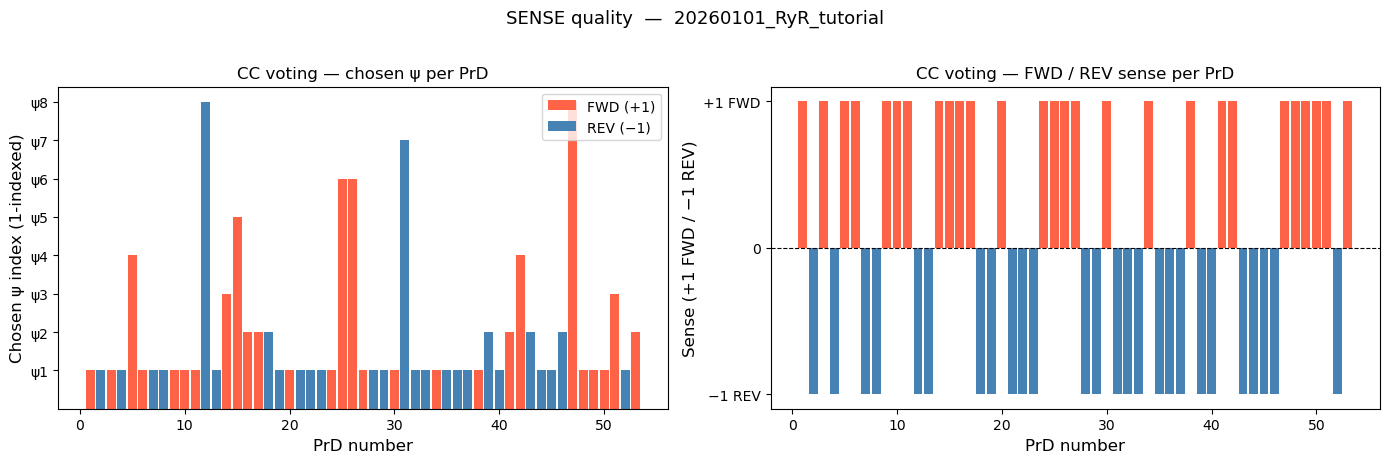

CC data loaded: 53 PrDs  |  ψ choices: {1: 35, 2: 8, 3: 2, 4: 2, 5: 1, 6: 2, 7: 1, 8: 2}


In [7]:
# ── Load CC voting results ─────────────────────────────────────────────────
cc_dir = output_dir / 'CC'
with open(cc_dir / 'CC_file.pkl', 'rb') as _f:
    cc_data = pickle.load(_f)

psinums_all = cc_data['psinums'][0]   # (P,)  0-indexed ψ choice per PrD
senses_all  = cc_data['senses'][0]    # (P,)  +1 FWD / -1 REV

n_prd_cc = len(psinums_all)
prd_nums  = np.arange(1, n_prd_cc + 1)

colors_sense = ['tomato' if s > 0 else 'steelblue' for s in senses_all]

fig_cc, axes_cc = plt.subplots(1, 2, figsize=(14, 4.5))

# ── Left: chosen ψ per PrD ─────────────────────────────────────────────────
bars = axes_cc[0].bar(prd_nums, psinums_all + 1, color=colors_sense,
                      edgecolor='none', width=0.85)
axes_cc[0].set_xlabel('PrD number', fontsize=12)
axes_cc[0].set_ylabel('Chosen ψ index (1-indexed)', fontsize=12)
axes_cc[0].set_title('CC voting — chosen ψ per PrD', fontsize=12)
axes_cc[0].set_yticks(range(1, 9))
axes_cc[0].set_yticklabels([f'ψ{k}' for k in range(1, 9)])

from matplotlib.patches import Patch
axes_cc[0].legend(
    handles=[Patch(fc='tomato', label='FWD (+1)'),
             Patch(fc='steelblue', label='REV (−1)')],
    fontsize=10, loc='upper right')

# ── Right: sense (+1/−1) per PrD ──────────────────────────────────────────
axes_cc[1].bar(prd_nums, senses_all,
               color=colors_sense, edgecolor='none', width=0.85)
axes_cc[1].axhline(0, color='k', lw=0.8, ls='--')
axes_cc[1].set_xlabel('PrD number', fontsize=12)
axes_cc[1].set_ylabel('Sense (+1 FWD / −1 REV)', fontsize=12)
axes_cc[1].set_title('CC voting — FWD / REV sense per PrD', fontsize=12)
axes_cc[1].set_yticks([-1, 0, 1])
axes_cc[1].set_yticklabels(['−1 REV', '0', '+1 FWD'])

plt.suptitle(f'SENSE quality  —  {project_name}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Update S2 sphere diamonds: colour by chosen ψ ─────────────────────────
# Move the ψ colorbar to x=1.20 so it sits to the right of the
# occupancy colorbar (which is at x=1.02) without overlapping.
psi_colormap = plt.cm.tab10
psi_colors = [f'rgb({int(r*255)},{int(g*255)},{int(b*255)})'
              for r,g,b,*_ in [psi_colormap(k/8) for k in psinums_all]]

with fig.batch_update():
    fig.data[2].marker.color  = psinums_all + 1  # 1-indexed
    fig.data[2].marker.colorscale = 'Turbo'
    fig.data[2].marker.colorbar = dict(
        title='Chosen ψ', thickness=14, x=1.20,
        tickvals=list(range(1, 9)), ticktext=[f'ψ{k}' for k in range(1, 9)],
    )
print(f"CC data loaded: {n_prd_cc} PrDs  |  ψ choices: {dict(zip(*np.unique(psinums_all+1, return_counts=True)))}")


In [8]:
cc_of_dir = cc_dir / 'CC_OF'

# ── ψ slider (1–8, independent of prd_slider) ─────────────────────────────
psi_of_slider = widgets.IntSlider(
    value=1, min=1, max=8, step=1,
    description='ψ:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='320px'),
)
of_out = widgets.Output()

def render_of(change):
    prd_num  = prd_slider.value
    pd_idx   = prd_num - 1
    psi_idx  = psi_of_slider.value - 1          # 0-indexed

    chosen_psi = int(psinums_all[pd_idx])        # 0-indexed
    star = ' ★' if psi_idx == chosen_psi else ''

    of_file = cc_of_dir / f'OF_prD_{pd_idx}.pkl'
    img_path = topos_dir / f'PrD_{prd_num}' / 'class_avg.png'

    with of_out:
        of_out.clear_output(wait=True)

        if not of_file.exists():
            print(f'OF file not found: {of_file}')
            return

        with open(of_file, 'rb') as _f:
            of_data = pickle.load(_f)

        fv = of_data['FlowVecPrD']
        if psi_idx >= len(fv) or fv[psi_idx] is None:
            print(f'No OF data for ψ{psi_idx+1} at PrD {prd_num}')
            return

        entry = fv[psi_idx]
        # sub-sample grid for quiver
        step = 16
        H, W = 336, 336
        ys = np.arange(step//2, H, step)
        xs = np.arange(step//2, W, step)
        Xg, Yg = np.meshgrid(xs, ys)

        fig_of, axes_of = plt.subplots(1, 2, figsize=(12, 5.5))
        for ax, direction, label in zip(axes_of, ['FWD', 'REV'], ['FWD (τ: 0→1)', 'REV (τ: 1→0)']):
            if direction not in entry:
                ax.text(0.5, 0.5, f'{direction} data missing', ha='center', va='center',
                        transform=ax.transAxes)
                continue
            vec = entry[direction]
            vx = np.asarray(vec['Vx'], dtype=float)
            vy = np.asarray(vec['Vy'], dtype=float)
            mag = np.asarray(vec['Mag'], dtype=float)

            if img_path.exists():
                bg = plt.imread(str(img_path))
                ax.imshow(bg, cmap='gray' if bg.ndim == 2 else None,
                          extent=[0, W, H, 0], origin='upper', alpha=0.6)
            else:
                ax.imshow(mag, cmap='hot', extent=[0, W, H, 0], origin='upper', alpha=0.4)

            # Pre-scale vectors so the 95th-percentile magnitude arrow spans ~70% of the
            # grid spacing — this gives consistent, visible arrows regardless of the raw
            # pixel-displacement magnitudes stored in the file.
            u_sub = vx[Yg, Xg]
            v_sub = -vy[Yg, Xg]  # flip y to match image coord orientation
            m_sub = np.sqrt(u_sub**2 + v_sub**2)
            ref_mag = float(np.percentile(m_sub[m_sub > 0], 95)) if (m_sub > 0).any() else 1e-9
            display_scale = (step * 0.70) / max(ref_mag, 1e-9)
            U = u_sub * display_scale
            V = v_sub * display_scale

            ax.quiver(Xg, Yg, U, V, mag[Yg, Xg],
                      cmap='plasma', scale=1.0, scale_units='xy', angles='xy',
                      width=0.004, headwidth=4, headlength=5, minlength=0.4)
            ax.set_xlim(0, W); ax.set_ylim(H, 0)
            ax.set_title(f'{label}   PrD {prd_num}  ψ{psi_idx+1}{star}', fontsize=11)
            ax.axis('off')

        plt.suptitle(f'Optical flow quiver  —  PrD {prd_num}  ψ{psi_idx+1}{star}', fontsize=12)
        plt.tight_layout()
        plt.show()

prd_slider.observe(render_of, names='value')
psi_of_slider.observe(render_of, names='value')
render_of(None)

display(widgets.VBox([
    widgets.HBox([prd_slider, psi_of_slider]),
    of_out,
]))


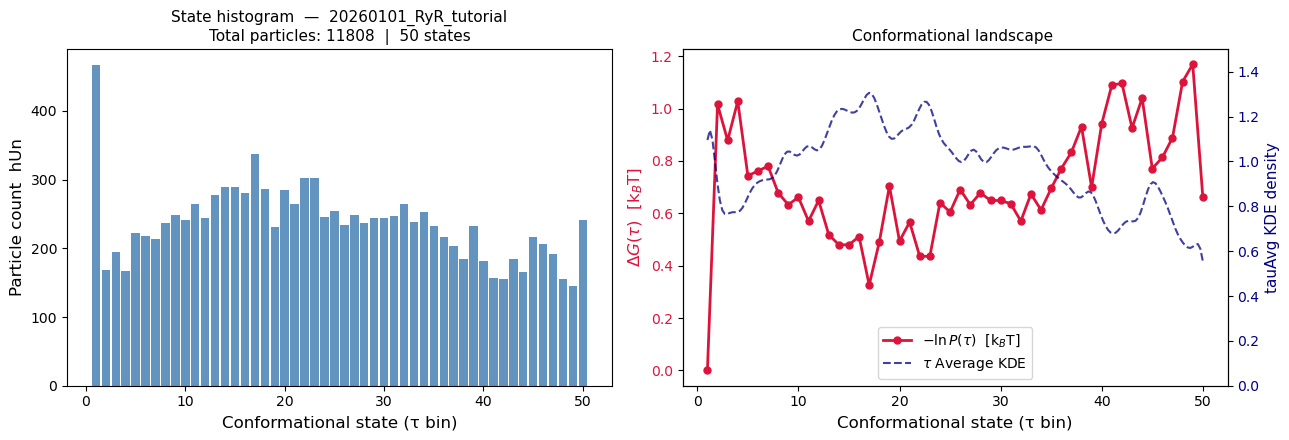

hUn: min=145  max=467  total=11808


In [9]:
traj_dir = output_dir / 'traj'

# ── Load trajectory summary data ──────────────────────────────────────────
with open(traj_dir / 'traj_name1.pkl', 'rb') as _f:
    traj_main = pickle.load(_f)
with open(traj_dir / 'traj_name1_vars.pkl', 'rb') as _f:
    traj_vars = pickle.load(_f)

hUn    = traj_main['hUn'].astype(float)     # (50,) — state histogram
tauAvg = traj_vars['tauAvg']                # (N,)  — per-particle τ

n_states = len(hUn)
state_ax = np.arange(1, n_states + 1)       # 1-indexed states

# ── Free energy —ln P(τ) ─────────────────────────────────────────────────
prob = hUn / hUn.sum()
prob_safe = np.where(prob > 0, prob, np.nan)
dG   = -np.log(prob_safe)
dG  -= np.nanmin(dG)                        # set minimum to 0

# ── KDE of tauAvg ─────────────────────────────────────────────────────────
tau_kde    = stats.gaussian_kde(tauAvg, bw_method=0.05)
tau_grid   = np.linspace(0, 1, 200)
tau_pdf    = tau_kde(tau_grid)

fig_prob, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histogram
ax1.bar(state_ax, hUn, color='steelblue', edgecolor='none', width=0.85, alpha=0.85)
ax1.set_xlabel('Conformational state (τ bin)', fontsize=12)
ax1.set_ylabel('Particle count  hUn', fontsize=12)
ax1.set_title(f'State histogram  —  {project_name}\n'
              f'Total particles: {int(hUn.sum())}  |  50 states', fontsize=11)

# Right: free energy + tauAvg KDE
ax2.plot(state_ax, dG, 'o-', color='crimson', lw=2, ms=5, label=r'$-\ln P(\tau)$  [k$_B$T]')
ax2.set_xlabel('Conformational state (τ bin)', fontsize=12)
ax2.set_ylabel(r'$\Delta G(\tau)$  [k$_B$T]', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

ax2b = ax2.twinx()
# Map tauAvg KDE (0-1) → state axis (1-50)
ax2b.plot(
    tau_grid * (n_states - 1) + 1, tau_pdf, '--',
    color='navy', lw=1.5, alpha=0.75, label=r'$\tau$ Average KDE'
)
ax2b.set_ylabel('tauAvg KDE density', fontsize=11, color='navy')
ax2b.tick_params(axis='y', labelcolor='navy')
ax2b.set_ylim(0, tau_pdf.max() * 1.15)  # add headroom

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(
    lines1 + lines2, labels1 + labels2,
    fontsize=10, loc='lower center',
    frameon=True
)

ax2.set_title('Conformational landscape ', fontsize=11)
fig_prob.subplots_adjust(top=0.82)  # leave space for legend above axes

plt.tight_layout()
plt.show()
print(f"hUn: min={hUn.min():.0f}  max={hUn.max():.0f}  total={hUn.sum():.0f}")
